# 01 — Data Quality and Exploratory Data Analysis

**GenAI Enterprise Adoption Intelligence Hub** (Northstar Financial Group / Northstar Assist — fictional)

> **Synthetic portfolio data.** Northstar Financial Group and Northstar Assist are fictional. All figures below are generated by `src/generate_synthetic_data.py` with a fixed random seed and must never be read as real enterprise data, real user behavior, or validated ROI. See `docs/assumptions_and_limitations.md` for the full integrity statement.

This notebook: (1) shows what the Phase 2 cleaning pipeline (`src/transform_data.py`) found and fixed in the raw data, and (2) explores the shape of the cleaned dataset before any adoption metrics are computed. It assumes `python src/generate_synthetic_data.py` and `python src/transform_data.py` have already been run from the repository root.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, os.path.abspath('..'))
from src import analysis as ga

NAVY, BLUE, LIGHT_BLUE, GRAY = '#1b3a6b', '#2f5f9e', '#5b8fc7', '#888888'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.facecolor'] = 'white'

RAW_DIR = os.path.join('..', 'data', 'raw')
PROCESSED_DIR = os.path.join('..', 'data', 'processed')

data = ga.load_data(PROCESSED_DIR)
for name, df in data.items():
    print(f'{name}: {len(df):,} rows, {df.shape[1]} columns')

users: 6,000 rows, 13 columns
events: 236,960 rows, 14 columns
feedback: 7,677 rows, 9 columns
training: 61 rows, 9 columns
features: 8 rows, 6 columns
calendar: 168 rows, 7 columns


## 1. What the cleaning pipeline found

The full log lives in `data/processed/data_quality_issues.csv`. Every row states an affected-record count, the resolution applied, and a status — nothing was silently dropped.

In [2]:
issues = pd.read_csv(os.path.join(PROCESSED_DIR, 'data_quality_issues.csv'))
pd.set_option('display.max_colwidth', 100)
issues

,issue_type,affected_record_count,resolution,status
0,Duplicate user_id rows in users.csv,8,"Removed exact-duplicate rows, keeping the first occurrence of each user_id.",Resolved
1,Inconsistent business_unit label variants in users.csv,16,"Normalized case/whitespace/abbreviation variants (e.g. 'RETAIL BANKING', 'TECH', 'Risk & Complia...",Resolved
2,Missing assigned_access_date in users.csv,155,Retained as null. These are predominantly users flagged eligible_for_access_flag=False who never...,Accepted
3,Missing manager_champion_flag in users.csv,60,Retained as null (unknown) rather than assumed False; excluded from champion-specific breakdowns...,Accepted
4,training_completed_date earlier than training_assigned_date in users.csv,0,Validated — no records found violating this business rule.,Validated (no issue found)
5,Duplicate event_id rows in usage_events.csv,950,"Removed exact-duplicate rows (simulated at-least-once delivery), keeping the first occurrence of...",Resolved
6,Invalid/unparseable event_timestamp in usage_events.csv,235,Quarantined (removed from clean output) — timestamp is required to place an event in a rollout w...,Resolved
7,Inconsistent feature_name label variants in usage_events.csv,2417,"Normalized case/whitespace/abbreviation variants (e.g. 'Doc Summarization', 'chat and research')...",Resolved
8,Missing feature_name in usage_events.csv,474,Retained as null; excluded from feature-level adoption metrics but included in overall activity/...,Accepted
9,Negative session_duration_seconds in usage_events.csv,708,"Nulled the impossible negative value. The event record itself is kept (event_type, feature_name,...",Resolved


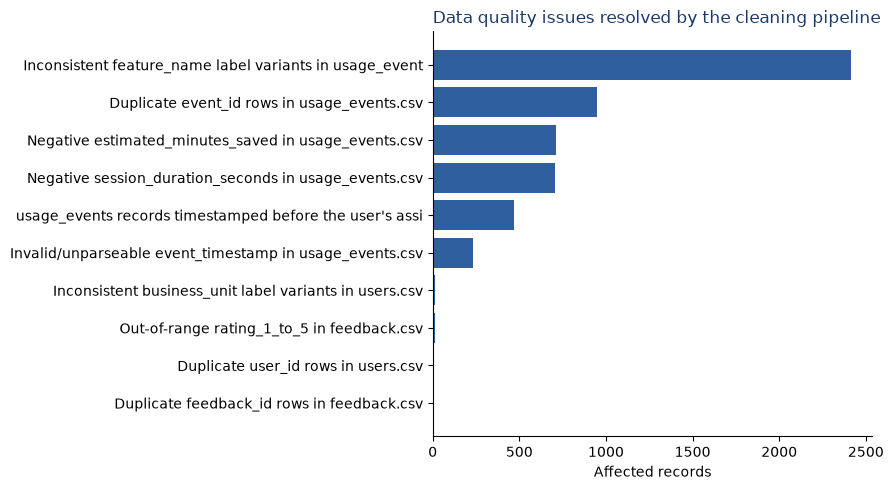

In [3]:
resolved = issues[issues['status'] == 'Resolved'].sort_values('affected_record_count', ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(resolved['issue_type'].str.slice(0, 55), resolved['affected_record_count'], color=BLUE)
ax.set_xlabel('Affected records')
ax.set_title('Data quality issues resolved by the cleaning pipeline', fontsize=12, color=NAVY, loc='left')
plt.tight_layout()
plt.show()

**Reading this chart:** each bar is a distinct issue category the pipeline detected and resolved (deduplication, label normalization, invalid-timestamp quarantine, negative-value nulling, and business-rule violations). Counts are not mutually exclusive — a single row can appear in more than one category.

## 2. Raw vs. processed row counts

Confirms what was removed (duplicates, quarantined timestamps, business-rule violations) versus what was merely relabeled or nulled in place.

In [4]:
raw_counts = {
    'users': len(pd.read_csv(os.path.join(RAW_DIR, 'users.csv'))),
    'usage_events': len(pd.read_csv(os.path.join(RAW_DIR, 'usage_events.csv'))),
    'feedback': len(pd.read_csv(os.path.join(RAW_DIR, 'feedback.csv'))),
}
processed_counts = {
    'users': len(data['users']),
    'usage_events': len(data['events']),
    'feedback': len(data['feedback']),
}
comparison = pd.DataFrame({'raw_rows': raw_counts, 'processed_rows': processed_counts})
comparison['rows_removed'] = comparison['raw_rows'] - comparison['processed_rows']
comparison

,raw_rows,processed_rows,rows_removed
users,6008,6000,8
usage_events,238617,236960,1657
feedback,7684,7677,7


## 3. Workforce composition (cleaned `users`)

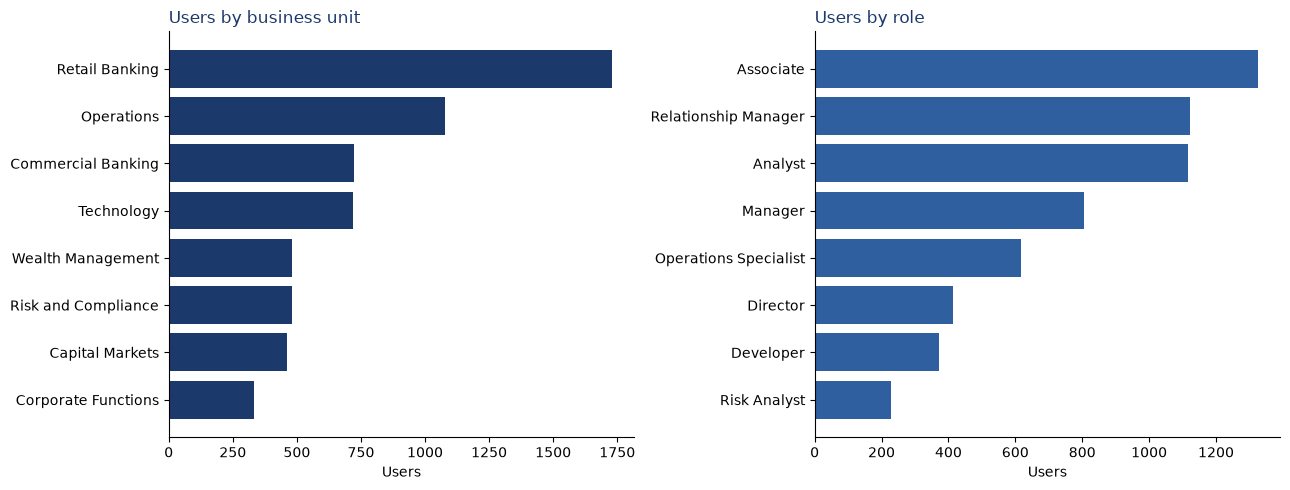

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bu_counts = data['users']['business_unit'].value_counts()
axes[0].barh(bu_counts.index[::-1], bu_counts.values[::-1], color=NAVY)
axes[0].set_title('Users by business unit', fontsize=12, color=NAVY, loc='left')
axes[0].set_xlabel('Users')

role_counts = data['users']['role'].value_counts()
axes[1].barh(role_counts.index[::-1], role_counts.values[::-1], color=BLUE)
axes[1].set_title('Users by role', fontsize=12, color=NAVY, loc='left')
axes[1].set_xlabel('Users')

plt.tight_layout()
plt.show()

## 4. Usage event composition (cleaned `usage_events`)

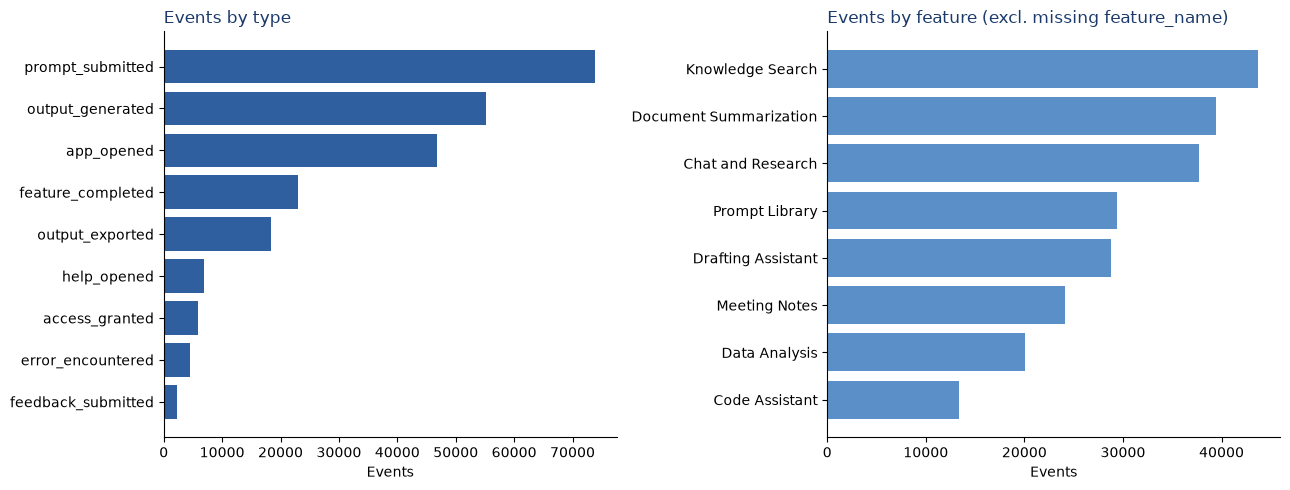

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

event_counts = data['events']['event_type'].value_counts()
axes[0].barh(event_counts.index[::-1], event_counts.values[::-1], color=BLUE)
axes[0].set_title('Events by type', fontsize=12, color=NAVY, loc='left')
axes[0].set_xlabel('Events')

feature_counts = data['events']['feature_name'].value_counts()
axes[1].barh(feature_counts.index[::-1], feature_counts.values[::-1], color=LIGHT_BLUE)
axes[1].set_title('Events by feature (excl. missing feature_name)', fontsize=12, color=NAVY, loc='left')
axes[1].set_xlabel('Events')

plt.tight_layout()
plt.show()

**Note:** `feature_name` is null for events that legitimately don't reference a specific feature (e.g. `access_granted`) or where the raw log had a missing value (documented and retained as null — see the quality log above); these are excluded from this chart, not fabricated.

## 5. Feedback composition (cleaned `feedback`)

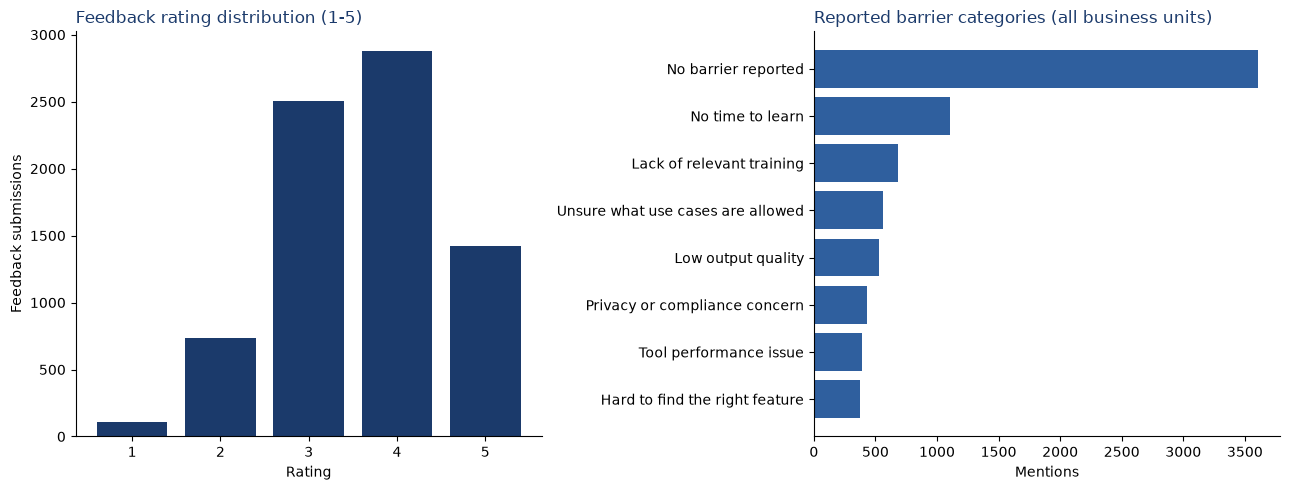

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rating_counts = data['feedback']['rating_1_to_5'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color=NAVY)
axes[0].set_title('Feedback rating distribution (1-5)', fontsize=12, color=NAVY, loc='left')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Feedback submissions')

barrier_counts = data['feedback']['barrier_category'].value_counts()
axes[1].barh(barrier_counts.index[::-1], barrier_counts.values[::-1], color=BLUE)
axes[1].set_title('Reported barrier categories (all business units)', fontsize=12, color=NAVY, loc='left')
axes[1].set_xlabel('Mentions')

plt.tight_layout()
plt.show()

## 6. Summary of EDA observations (synthetic data)

- The cleaning pipeline resolved 15 distinct issue categories with corrective action (dedup, normalization, nulling, quarantine/removal) and validated 4 more with zero violations found — see the full log for exact counts.
- Retail Banking and Operations make up the largest share of the (synthetic) workforce, consistent with the project's designed scenario of high headcount but mixed engagement.
- `prompt_submitted` and `output_generated` dominate the event mix, as expected for a chat-style assistant; `Knowledge Search` and `Document Summarization` are the most-used features, matching the scenario's "broadly adopted" design intent.
- Feedback ratings skew positive but with a real negative tail, and "No time to learn" / "Lack of relevant training" are common reported barriers — set up for a closer adoption and barrier analysis in `02_adoption_analysis.ipynb`.

**Caveat:** every pattern above was designed into the synthetic data generator to make the dataset realistic enough for analysis practice. None of it should be read as evidence about how a real GenAI rollout would behave.